<a href="https://colab.research.google.com/github/sbeeredd04/sandbox/blob/main/token-opt/notebooks/clip_opt_ctok_softvq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLIP-Guided Test-Time Optimization with Continuous Tokenizer (SoftVQ)

This notebook demonstrates CLIP-guided image editing using the Continuous Tokenizer with SoftVQ quantization instead of TiTok.

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

In [2]:
import sys
if IN_COLAB:
    !git clone -q https://github.com/sbeeredd04/sandbox.git
    !pip install -q --progress-bar off jaxtyping open_clip_torch omegaconf
    sys.path.insert(0, "sandbox/token-opt")
    sys.path.insert(0, "sandbox/continuous_tokenizer")
else:
    sys.path.insert(0, "..")

In [3]:
import os
# Set this environment for deterministic execution
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [4]:
import torch
# Enable for deterministic algorithms
torch.use_deterministic_algorithms(True, warn_only=False)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

from pathlib import Path
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as v2
import torchvision.transforms.v2.functional as tvf
from torchvision.datasets import ImageNet
from einops import rearrange

In [5]:
from tto.test_time_opt import (
    TestTimeOpt,
    TestTimeOptConfig,
    CLIPObjective,
)

/content/sandbox/continuous_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2186: UserWarning: Overwriting vit_tiny_patch16_224 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/sandbox/continuous_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2205: UserWarning: Overwriting vit_tiny_patch16_384 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_384. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/sandbox/continuous_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2214: UserWarning: Overwriting vit_small_patch32_224 in registry with modelling.modules.timm_vit.vision_transformer.vit_small_patch32_224. This is because the name being registered conflicts with an exis

In [ ]:
#config variables
gpus = "8,9"

In [6]:
# Set visible gpus
# use_gpu = False
# if use_gpu:

#     os.environ["CUDA_VISIBLE_DEVICES"] = gpus
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Using device with ids: {os.environ['CUDA_VISIBLE_DEVICES']}")

# else:
#     device = torch.device("cpu")
#     print("Using CPU device")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Utils

In [14]:
def load_img(path, device=None):
    if IN_COLAB:
        path = Path("sandbox/token-opt/notebooks") / Path(path)
    img = (1. / 255.) * torch.from_numpy(
        np.array(Image.open(path)).astype(np.float32)
    ).permute(2, 0, 1)
    img = tvf.resize(img, 256)
    img = tvf.center_crop(img, 256)
    img = img.unsqueeze(0)
    if device is not None:
        img = img.to(device)
    return img

def display_image(*tensors):
    tensors = [255. * t.squeeze() for t in tensors]
    img = Image.fromarray(rearrange(
        tensors, "b c h w -> h (b w) c"
    ).to("cpu", dtype=torch.uint8).numpy())
    display(img)

def opt_callback(info):
    if info.i % 50 == 0:
        print(f"i = {info.i}")
        print("  CLIP score =", "\t".join(
            map(lambda l: f"{-l:.3f}", info.loss))
        )
        imgs = tto.decode(info.tokens).clamp(0., 1.)
        display_image(*imgs)

In [8]:
# Use CLIP similarity maximization objective
objective = CLIPObjective(num_augmentations=8, cfg_scale=1.2)

# Set prompt
objective.prompt = [
    "a photo of a tiger",
    "a photo of a husky",
    "a photo of a sparrow",
]

# Optionally set a negative prompt
# Note: also need to set cfg_scale > 1 in CLIPObjective if using this!
objective.neg_prompt = "bad, low-res, unnatural"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [11]:
tto_config = TestTimeOptConfig(
    # Use continuous tokenizer with SoftVQ model
    # Format: "continuous_tokenizer:MODEL_TYPE:CHECKPOINT_PATH" (optional checkpoint path)
    titok_checkpoint="continuous_tokenizer:SoftVQ:SoftVQVAE/softvq-l-64",

    # Optimize in continuous space (before quantization)
    optimize_post_quantization_tokens=False,

    # VAE sampling (deterministic for reproducibility)
    vae_deterministic_sampling=True,

    # Optimization parameters (same as original)
    num_iter=301,
    ema_decay=0.98,
    lr=1e-1,
    enable_amp=True,
    reg_weight=0.025,
    #token_noise=1e-3,
    reg_type="seed",
)
tto = TestTimeOpt(tto_config, objective).to(device)

Using Continuous Tokenizer (SoftVQ)!


model.safetensors:   0%|          | 0.00/2.43G [00:00<?, ?B/s]

Missing keys: 2


# Load seed images

In [15]:
# Load seed image
img = torch.cat([
    load_img("ILSVRC2012_val_00008636.png", device),
    load_img("ILSVRC2012_val_00008636.png", device),
    load_img("ILSVRC2012_val_00010240.png", device),
], dim=0)

# Alternatively, initialize directly from given tokens (e.g. randomly
# sampled), but this is disabled when setting `seed_tokens = None`.
seed_tokens = None

# Run Optimization

Seed


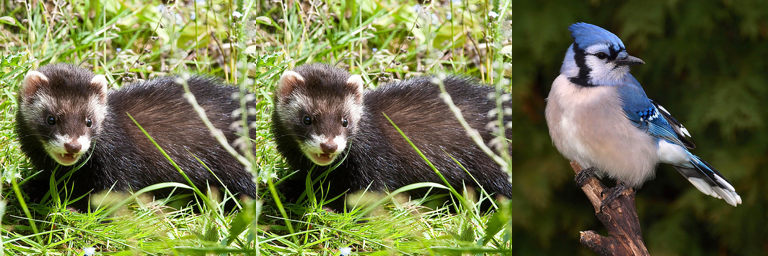

Encoding seed image to tokens...


/content/sandbox/token-opt/tto/test_time_opt.py:233: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=self.config.enable_amp)  # For mixed precision training


Initial tokens shape: torch.Size([3, 32, 1, 64])


Optimization Iterations:   0%|          | 0/301 [00:00<?, ?it/s]

i = 0
  CLIP score = 0.097	0.108	0.198


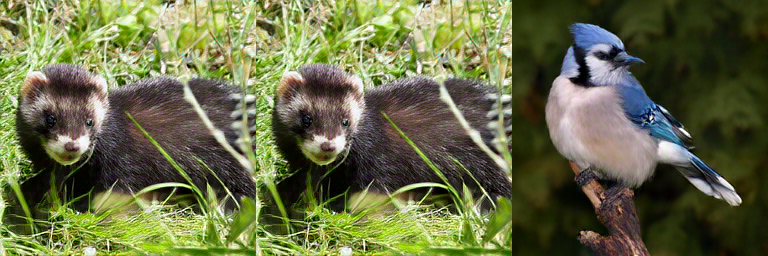

Optimization Iterations:  17%|█▋        | 50/301 [00:15<01:10,  3.57it/s]

i = 50
  CLIP score = 0.308	0.343	0.370


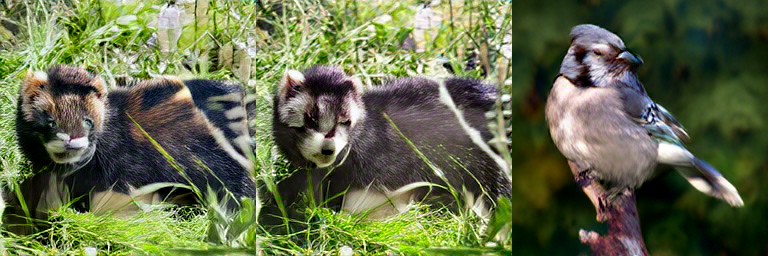

Optimization Iterations:  33%|███▎      | 100/301 [00:30<00:57,  3.53it/s]

i = 100
  CLIP score = 0.335	0.366	0.387


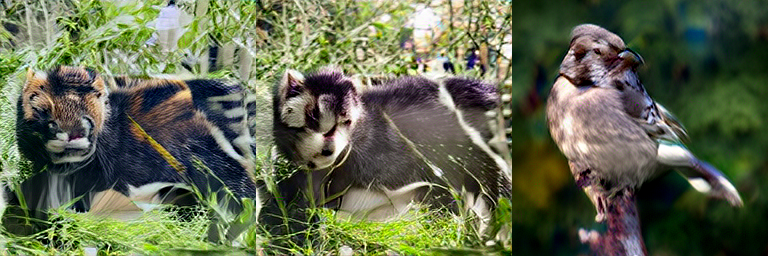

Optimization Iterations:  50%|████▉     | 150/301 [00:45<00:45,  3.35it/s]

i = 150
  CLIP score = 0.342	0.376	0.393


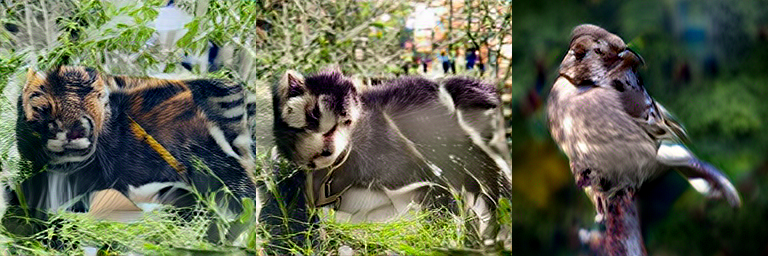

Optimization Iterations:  66%|██████▋   | 200/301 [01:00<00:30,  3.37it/s]

i = 200
  CLIP score = 0.348	0.381	0.396


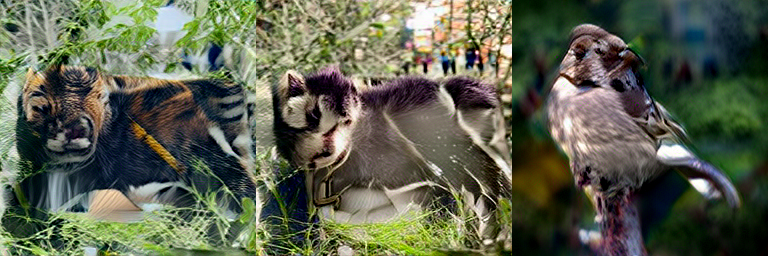

Optimization Iterations:  83%|████████▎ | 250/301 [01:15<00:14,  3.49it/s]

i = 250
  CLIP score = 0.354	0.389	0.406


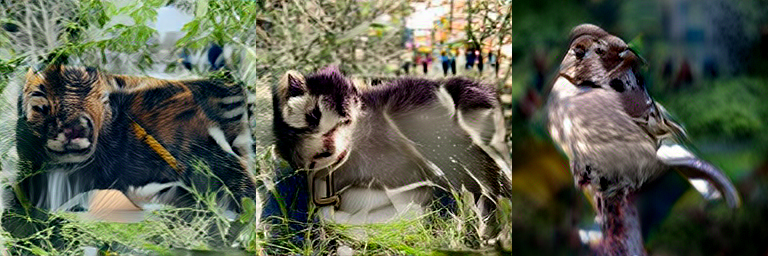

Optimization Iterations: 100%|█████████▉| 300/301 [01:29<00:00,  3.52it/s]

i = 300
  CLIP score = 0.354	0.390	0.406


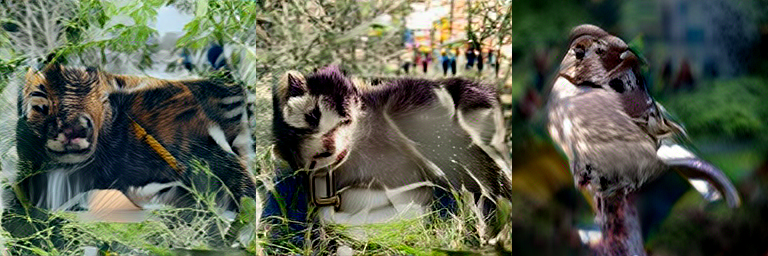

Optimization Iterations: 100%|██████████| 301/301 [01:30<00:00,  3.33it/s]


In [16]:
print("Seed")
display_image(*img)

# Run optimization
torch.manual_seed(0)
img_opt = tto(
    seed=img if seed_tokens is None else None,
    seed_tokens=seed_tokens,
    callback=opt_callback
)

In [ ]:
import torch
import numpy as np
from PIL import Image
from pathlib import Path
import torchvision.transforms.v2.functional as tvf
from einops import rearrange
import sys
sys.path.insert(0, "..")

from tto.continuous_tokenizer_wrapper import ContinuousTokenizerWrapper


def load_img(path, device=None):
    img = (1. / 255.) * torch.from_numpy(
        np.array(Image.open(path)).astype(np.float32)
    ).permute(2, 0, 1)
    img = tvf.resize(img, 256)
    img = tvf.center_crop(img, 256)
    img = img.unsqueeze(0)
    if device is not None:
        img = img.to(device)
    return img


def save_img(tensor, path):
    tensor = tensor.squeeze().clamp(0., 1.) * 255.
    img = Image.fromarray(tensor.permute(1, 2, 0).cpu().to(dtype=torch.uint8).numpy())
    img.save(path)


def encode_tokens(model, img, quantize=False):
    with torch.no_grad():
        h = model.encode(pixel_values=img)
        h = h.transpose(1, 2).unsqueeze(2)
        
        if quantize:
            h_flat = h.squeeze(2).transpose(1, 2)
            quant, losses, info = model.quantize(h_flat)
            h = quant.transpose(1, 2).unsqueeze(2)
        
        return h


def decode_tokens(model, tokens, quantize=False):
    with torch.no_grad():
        if quantize:
            tokens_flat = tokens.squeeze(2).transpose(1, 2)
            quant, losses, info = model.quantize(tokens_flat)
            tokens = quant.transpose(1, 2).unsqueeze(2)
        
        tokens_decode = tokens.squeeze(2).transpose(1, 2)
        img = model.decode(tokens_decode)
        return img


def swap_token(tokens1, tokens2, token_idx):
    tokens_swapped = tokens1.clone()
    tokens_swapped[:, :, :, token_idx] = tokens2[:, :, :, token_idx]
    return tokens_swapped


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ContinuousTokenizerWrapper(
    checkpoint_path="SoftVQVAE/softvq-l-64",
    model_type='SoftVQ',
    num_latent_tokens=64,
    codebook_embed_dim=32,
).to(device)
model.eval()

quantize_tokens = False

img1 = load_img("ILSVRC2012_val_00008636.png", device)
img2 = load_img("ILSVRC2012_val_00010240.png", device)

tokens1 = encode_tokens(model, img1, quantize=quantize_tokens)
tokens2 = encode_tokens(model, img2, quantize=quantize_tokens)

print(f"Tokens shape: {tokens1.shape}")

save_img(img1, "original1.png")
save_img(img2, "original2.png")

recon1 = decode_tokens(model, tokens1, quantize=quantize_tokens)
save_img(recon1, "recon1.png")

for token_idx in [0, 16, 32, 48, 63]:
    tokens_swapped = swap_token(tokens1, tokens2, token_idx)
    img_swapped = decode_tokens(model, tokens_swapped, quantize=quantize_tokens)
    save_img(img_swapped, f"swapped_token_{token_idx}.png")
    print(f"Swapped token {token_idx}, saved to swapped_token_{token_idx}.png")

